In [4]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score,davies_bouldin_score


In [5]:
df = pd.read_csv('iris.csv')

In [7]:
x = df.drop(columns=['species'])

In [8]:
x.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
model = KMeans(n_clusters=3,random_state=42)
model.fit(x)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [10]:
cluster = model.predict(x)

In [11]:
x['cluster'] = cluster

In [12]:
x['cluster'].value_counts()

cluster
2    61
1    50
0    39
Name: count, dtype: int64

In [13]:
ss = silhouette_score(x,cluster)
dbs = davies_bouldin_score(x,cluster)

In [14]:
print("Silhouette Score:", ss)
print("Davies-Bouldin Score:", dbs)

Silhouette Score: 0.6844657470953515
Davies-Bouldin Score: 0.47949409665560555


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

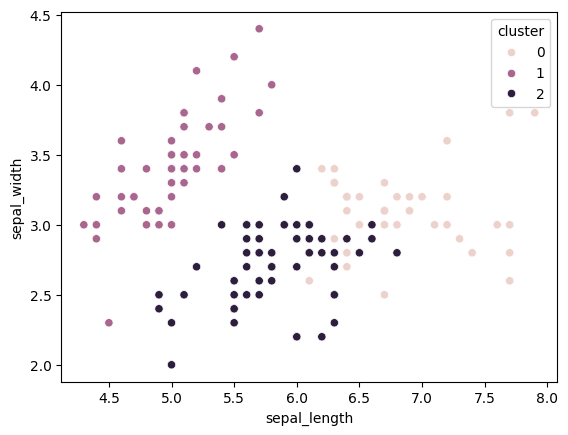

In [18]:
sns.scatterplot(data=x, x='sepal_length', y='sepal_width', hue='cluster')

In [19]:
ini = []
k = range(1,11)
for i in k:
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(x)
    ini.append(km.inertia_)
    

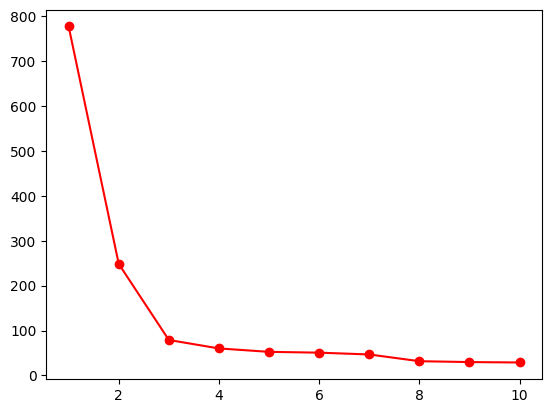

In [26]:
plt.plot(k,ini,'ro-')
plt.show()